# Topic modeling

## 0. Libraries import

In [1]:
import pandas as pd
import numpy as np
import ast
import gensim
import gensim.corpora as corpora
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import nltk
import string 
import re
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

In [2]:
from gensim.models import LdaModel
from gensim.corpora import Dictionary
from gensim.models import LdaMulticore
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from collections import Counter
from gensim.models import CoherenceModel
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score

## 1. Data import

In [4]:
DATA_PATH = "kickstarter_processed.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(6507, 15)


,url,title,description,pledged,usd_pledged,converted_pledged_amount,goal,currency,category,video,reached,status,duration,description_processed,pos_tagged
0,https://www.kickstarter.com/projects/thetruthb...,NaN,The PROBLEM: So much entertainment today pushe...,71123.0,71123.0,61607,48000.0,USD,Film & Video,1,148.172917,1,30,"['problem', 'much', 'entertainment', 'today', ...","[('problem', 'NN'), ('much', 'JJ'), ('entertai..."
1,https://www.kickstarter.com/projects/99625582/...,NaN,Millions of American college students have stu...,65318.0,65318.0,56579,61500.0,USD,Film & Video,1,106.208130,1,41,"['million', 'american', 'college', 'student', ...","[('million', 'CD'), ('american', 'JJ'), ('coll..."
2,https://www.kickstarter.com/projects/distortre...,Cartoon Network Alphabet Pins,Full A-Z Set I'm launching this set to show my...,462.0,462.0,400,8000.0,USD,Film & Video,1,5.775000,0,45,"['full', 'z', 'set', 'launch', 'set', 'show', ...","[('full', 'JJ'), ('z', 'NN'), ('set', 'VBN'), ..."
3,https://www.kickstarter.com/projects/jordym/th...,The Balloon - a short film,"On a sleepy summer afternoon, we stared into t...",5137.0,5137.0,4449,15000.0,USD,Film & Video,1,34.246667,0,60,"['sleepy', 'summer', 'afternoon', 'star', 'voi...","[('sleepy', 'NN'), ('summer', 'NN'), ('afterno..."
4,https://www.kickstarter.com/projects/trans-mov...,NaN,48 hours of pledge matching! Amazing news! Two...,50640.0,50640.0,43865,50000.0,USD,Film & Video,1,101.280000,1,30,"['hour', 'pledge', 'match', 'amaze', 'news', '...","[('hour', 'NN'), ('pledge', 'NN'), ('match', '..."


## 2. Latent Dirichlet Analysis (LDA)

### 2.1 Bag of Words creation

The Bag-of-Words representation is constructed separately for each category to capture category-specific vocabulary and thematic structure. Texts are tokenized using the preprocessed descriptions, and a dictionary is built for each category-specific corpus. To improve representation quality and reduce noise, extreme terms are filtered using document frequency thresholds. Although a global filtering step was already applied during preprocessing, additional category-level filtering is necessary. Terms that are frequent across the full dataset may still dominate within a specific category, reducing the model’s ability to capture discriminative patterns. Applying filtering within each category removes locally non-informative terms and improves feature relevance. Specifically, terms that appear in fewer than 5 documents or in more than 40% of documents within a category are removed. This balances the trade-off between retaining informative terms and excluding overly rare or overly common ones. The choice of thresholds is heuristic and may affect the resulting topics. The resulting dictionaries and corpora are then used to fit category-specific topic models.

In [5]:
categories = df['category'].unique()

results = []
dictionaries_by_category = {}
corpora_by_category = {}

for cat in categories:
    df_cat = df[df['category'] == cat]

    # Tokenization
    texts_cat = df_cat['description_processed'].apply(lambda x: x.split()).tolist()

    # Category dictionary 
    dictionary_cat = Dictionary(texts_cat)

    vocab_before = len(dictionary_cat)

    # Removing words that appear in more than 40% of documents and in less than 5 documents 
    dictionary_cat.filter_extremes(no_below = 5, no_above = 0.4)

    vocab_after = len(dictionary_cat)

    # Bag of Words creation
    corpus_cat = [dictionary_cat.doc2bow(text) for text in texts_cat]

    dictionaries_by_category[cat] = dictionary_cat
    corpora_by_category[cat] = corpus_cat

    results.append({
        "Category": cat,
        "Documents": len(texts_cat),
        "Vocab before filtering": vocab_before,
        "Vocab after filtering": vocab_after,
        "Removed words": vocab_before - vocab_after
    })

bow_summary = pd.DataFrame(results)
bow_summary

,Category,Documents,Vocab before filtering,Vocab after filtering,Removed words
0,Film & Video,1834,17150,10187,6963
1,Games,1115,15797,8150,7647
2,Music,1112,13485,5284,8201
3,Publishing,1088,15655,7501,8154
4,Technology,1358,14468,7423,7045


### 2.2 Coherence scores

Coherence scores are used to guide the selection of the number of topics for each category. Since Latent Dirichlet Allocation (LDA) does not provide an intrinsic criterion to determine the optimal number of topics, multiple values of \(k\) are evaluated over a predefined range. For each value of \(k\), a separate model is trained on the corresponding category-specific corpus, and the coherence score (C_V) is computed. The C_V metric is used as the primary evaluation measure, as it captures the semantic coherence of topics by assessing the co-occurrence patterns of high-probability words. The resulting scores allow for comparison across different values of \(k\) within each category and support the selection of a configuration that balances interpretability and model quality. Coherence is a proxy for interpretability and does not guarantee that topics are meaningful for downstream analysis.

In [6]:
topic_range = range(2, 9)

coherence_results = []
lda_models_by_category = {}

for cat in categories:
    dictionary_cat = dictionaries_by_category[cat]
    corpus_cat = corpora_by_category[cat]

    df_cat = df[df['category'] == cat]
    texts_cat = df_cat['description_processed'].apply(lambda x: x.split()).tolist()

    lda_models_by_category[cat] = {}

    for k in topic_range:
        lda_model = LdaMulticore(
            corpus = corpus_cat,
            id2word = dictionary_cat,
            num_topics = k,
            passes = 10,
            workers = 2,
            random_state = 11
        )

        coherence_cv = CoherenceModel(
            model = lda_model,
            texts = texts_cat,
            dictionary = dictionary_cat,
            coherence = 'c_v'
        ).get_coherence()

        lda_models_by_category[cat][k] = lda_model

        coherence_results.append({
            "Category": cat,
            "Topics (k)": k,
            "C_V": coherence_cv
        })

# DataFrame
cv_summary = pd.DataFrame(coherence_results)

cv_summary = cv_summary.sort_values(
    by = ["Category", "Topics (k)"]
).reset_index(drop = True)

cv_pivot = cv_summary.pivot(
    index = "Category",
    columns = "Topics (k)",
    values = "C_V"
)

cv_pivot.round(4)

Topics (k),2,3,4,5,6,7,8
Category,,,,,,,
Film & Video,0.4303,0.3914,0.3736,0.3598,0.3552,0.3549,0.3506
Games,0.3825,0.3759,0.3696,0.4041,0.3890,0.3929,0.3834
Music,0.3487,0.3689,0.4031,0.3972,0.3634,0.4098,0.3844
Publishing,0.4106,0.3793,0.4735,0.4591,0.4286,0.4230,0.4348
Technology,0.3117,0.3733,0.3860,0.4100,0.4244,0.4245,0.4151


Based on the coherence analysis, the selected number of topics varies across categories, reflecting differences in corpus structure and thematic diversity. Film & Video is best represented by a small number of topics (\(k = 2\)), consistent with the decreasing coherence trend as \(k\) increases. Games achieves its highest coherence at \(k = 5\), although the variation across nearby values is limited, suggesting that multiple configurations could be reasonable. Music and Technology both reach their highest coherence at \(k = 7\), indicating that a richer topic structure better captures the variability of these categories. Publishing shows the highest coherence at an intermediate value (\(k = 4\)), balancing topic granularity and interpretability. Overall, the selected values of \(k\) correspond to the highest observed coherence scores, but the differences across adjacent configurations are often modest. For this reason, the final choice should be interpreted as a practical compromise between coherence and interpretability, rather than a uniquely optimal solution.

In [7]:
best_k = cv_summary.loc[
    cv_summary.groupby("Category")["C_V"].idxmax()
][["Category", "Topics (k)", "C_V"]]

best_k = best_k.rename(columns={"Topics (k)": "Best k"}).round(4)

best_k

,Category,Best k,C_V
0,Film & Video,2,0.4303
10,Games,5,0.4041
19,Music,7,0.4098
23,Publishing,4,0.4735
33,Technology,7,0.4245


### Coherence scores visualization

Coherence scores are analyzed across different values of \( k \) to guide the selection of the number of topics for each category.

The patterns differ substantially across domains. In Film & Video, coherence decreases as \( k \) increases, indicating that simpler topic structures provide more consistent representations. In contrast, Music, Publishing, and Technology show clear improvements at intermediate or higher values of \( k \), with identifiable peaks suggesting more granular topic decompositions are beneficial. Games exhibits relatively flat behavior, with only modest variation across \( k \), pointing to weak sensitivity to the number of topics.

Importantly, coherence differences across neighboring values of \( k \) are generally small. This suggests that multiple configurations yield comparable topic quality, and that the selected \( k \) should be interpreted as a practical choice rather than a uniquely optimal solution.

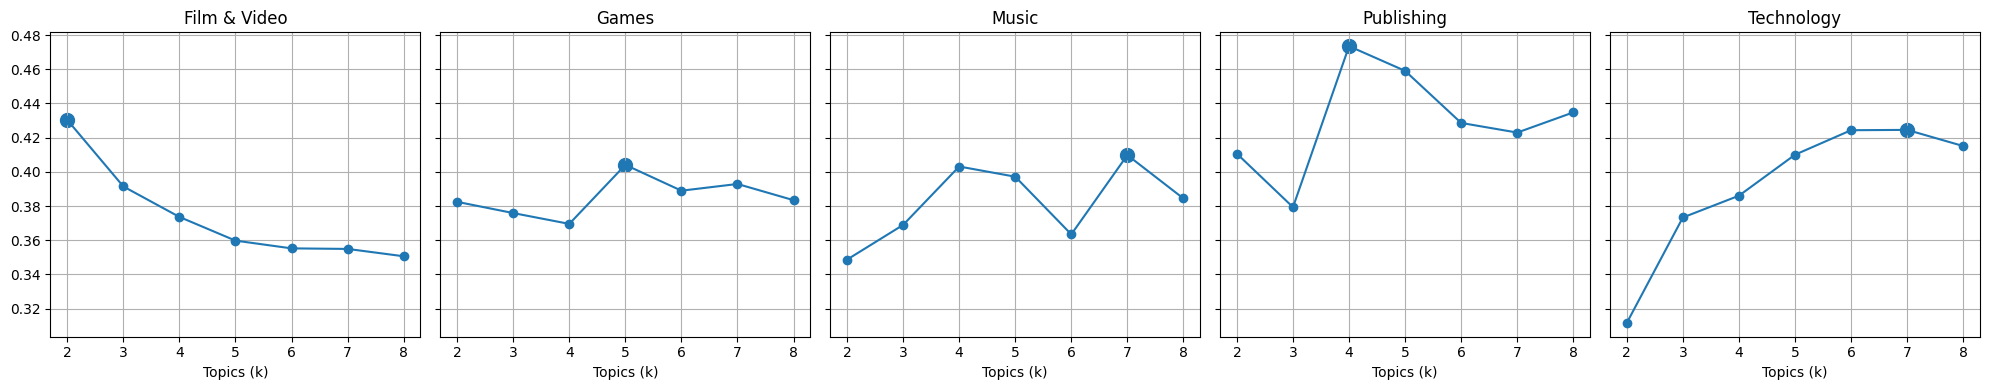

In [8]:
categories_order = cv_summary["Category"].unique()

fig, axes = plt.subplots(
    1,
    len(categories_order),
    figsize = (20, 4),  
    sharex = True,
    sharey = True       
)

for i, cat in enumerate(categories_order):
    ax = axes[i]
    
    data_cat = cv_summary[
        cv_summary["Category"] == cat
    ].sort_values("Topics (k)")
    
    ax.plot(data_cat["Topics (k)"], data_cat["C_V"], marker = "o")
    
    # best number of topics
    best_row = data_cat.loc[data_cat["C_V"].idxmax()]
    ax.scatter(best_row["Topics (k)"], best_row["C_V"], s = 100)
    
    ax.set_title(cat)
    ax.set_xlabel("Topics (k)")
    ax.grid(True)

plt.tight_layout()
plt.show()

### 2.3 Identification of the main topics

After selecting the number of topics for each category, a final LDA model is trained separately on each category-specific corpus using the corresponding value of \(k\).

For each model, the most representative words are extracted for every topic. In particular, the top 15 words with the highest probability within each topic are selected and stored in a structured table. Results are reported separately by category to facilitate comparison.

A preliminary inspection of the extracted topics shows variation in their level of distinctiveness. In some categories, topics are clearly separated, with well-defined sets of high-probability words. In others, there is partial overlap across topics, suggesting that some themes share a common vocabulary. Topic interpretation is qualitative and depends on the inspection of high-probability words; no external validation of topic meaning is performed.

In [9]:
topic_words_results = []

for _, row in best_k.iterrows():
    cat = row["Category"]
    k = int(row["Best k"])

    dictionary_cat = dictionaries_by_category[cat]
    corpus_cat = corpora_by_category[cat]

    lda_model = LdaMulticore(
        corpus = corpus_cat,
        id2word = dictionary_cat,
        num_topics = k,
        passes = 10,
        workers = 2,
        random_state = 11
    )

    for topic_id in range(k):
        words = lda_model.show_topic(topic_id, topn = 15)  
        top_words = ", ".join([word for word, weight in words])

        topic_words_results.append({
            "Category": cat,
            "Topic": topic_id + 1,
            "Top words": top_words
        })

topics_table = pd.DataFrame(topic_words_results)

topics_table = topics_table.sort_values(
    by = ["Category", "Topic"]
).reset_index(drop=True)

for cat in topics_table["Category"].unique():
    k = int(best_k[best_k["Category"] == cat]["Best k"].values[0])
    
    display(
        topics_table[topics_table["Category"] == cat][["Topic", "Top words"]]
        .style.set_caption(f"{cat} — {k} topics")
    )

,Topic,Top words
0,1,"'award',, 'actor',, 'writer',, 'woman',, 'documentary',, 'filmmaker',, 'school',, 'artist',, 'win',, 'york',, 'direct',, 'family',, 'series',, 'american',, 'university',"
1,2,"'reward',, 'series',, 'episode',, 'video',, 'animation',, 'community',, 'backer',, 'cost',, 'pledge',, 'money',, 'digital',, 'reach',, 'budget',, 'thank',, 'right',"


,Topic,Top words
2,1,"'content',, 'controller',, 'sound',, 'system',, 'app',, 'product',, 'video',, 'button',, 'development',, 'device',, 'control',, 'user',, 'console',, 'n',, 'switch',"
3,2,"'card',, 'deck',, 'dice',, 'box',, 'tarot',, 'shipping',, 'edition',, 'book',, 'print',, 'rule',, 'color',, 'order',, 'expansion',, 'board',, 'pack',"
4,3,"'book',, 'digital',, 'dice',, 'adventure',, 'table',, 'print',, 'tier',, 'monster',, 'fantasy',, 'pdf',, 'map',, 'item',, 'system',, 'shipping',, 'edition',"
5,4,"'puzzle',, 'piece',, 'book',, 'crossword',, 'board',, 'print',, 'solve',, 'color',, 'page',, 'artist',, 'tier',, 'name',, 'dance',, 'thing',, 'kid',"
6,5,"'battle',, 'system',, 'tier',, 'adventure',, 'development',, 'skill',, 'item',, 'event',, 'enemy',, 'ability',, 'gameplay',, 'learn',, 'access',, 'release',, 'combat',"


,Topic,Top words
7,1,"'n',, 'jazz',, 'art',, 'student',, 'piano',, 'festival',, 'event',, 'musical',, 'inspire',, 'home',, 'book',, 'school',, 'program',, 'hop',, 'workshop',"
8,2,"'day',, 'tour',, 'feel',, 'dream',, 'band',, 'show',, 'guitar',, 'hope',, 'producer',, 'full',, 'last',, 'thing',, 'best',, 'family',, 'journey',"
9,3,"'money',, 'ep',, 'show',, 'full',, 'thing',, 'best',, 'day',, 'band',, 'great',, 'reach',, 'really',, 'process',, 'put',, 'good',, 'raise',"
10,4,"'band',, 'vinyl',, 'track',, 'jazz',, 'set',, 'original',, 'press',, 'engineer',, 'art',, 'cover',, 'vocal',, 'bass',, 'full',, 'edition',, 'session',"
11,5,"'god',, 'church',, 'worship',, 'sing',, 'jesus',, 'hope',, 'begin',, 'heart',, 'great',, 'believe',, 'book',, 'family',, 'faith',, 'call',, 'producer',"
12,6,"'shirt',, 'radio',, 'reach',, 'great',, 'money',, 'god',, 'produce',, 'receive',, 'pay',, 'thing',, 'day',, 'put',, 'ask',, 'may',, 'believe',"
13,7,"'composer',, 'perform',, 'jazz',, 'musical',, 'concert',, 'piece',, 'performance',, 'orchestra',, 'art',, 'ensemble',, 'film',, 'piano',, 'classical',, 'american',, 'award',"


,Topic,Top words
14,1,"'woman',, 'deck',, 'change',, 'card',, 'learn',, 'self',, 'community',, 'plan',, 'thing',, 'build',, 'become',, 'guide',, 'good',, 'say',, 'china',"
15,2,"'child',, 'community',, 'family',, 'kid',, 'learn',, 'show',, 'little',, 'series',, 'music',, 'magazine',, 'school',, 'reader',, 'illustration',, 'young',, 'thank',"
16,3,"'edition',, 'add',, 'ship',, 'backer',, 'pledge',, 'tier',, 'sign',, 'copy',, 'artist',, 'special',, 'stretch',, 'hardcover',, 'receive',, 'color',, 'digital',"
17,4,"'magazine',, 'fiction',, 'writer',, 'anthology',, 'award',, 'issue',, 'editor',, 'poetry',, 'black',, 'artist',, 'short',, 'press',, 'word',, 'fantasy',, 'collection',"


,Topic,Top words
18,1,"'camera',, 'battery',, 'charge',, 'light',, 'quality',, 'phone',, 'pro',, 'usb',, 'watch',, 'color',, 'hand',, 'sound',, 'mount',, 'app',, 'smartphone',"
19,2,"'sound',, 'audio',, 'music',, 'speaker',, 'sleep',, 'bluetooth',, 'headphone',, 'quality',, 'app',, 'body',, 'track',, 'band',, 'fit',, 'ear',, 'data',"
20,3,"'sensor',, 'kit',, 'board',, 'robot',, 'software',, 'learn',, 'program',, 'open',, 'battery',, 'hardware',, 'data',, 'prototype',, 'student',, 'pi',, 'run',"
21,4,"'game',, 'space',, 'module',, 'kit',, 'model',, 'board',, 'motion',, '3d',, 'mode',, 'controller',, 'reward',, 'program',, 'mission',, 'light',, 'input',"
22,5,"'print',, 'light',, '3d',, 'cut',, 'clean',, 'material',, 'machine',, 'sound',, 'water',, 'printer',, 'box',, 'laser',, 'browser',, 'precision',, 'html5',"
23,6,"'app',, 'learn',, 'sound',, 'home',, 'community',, 'family',, 'child',, 'content',, 'pet',, 'kid',, 'dog',, 'would',, 'grow',, 'day',, 'browser',"
24,7,"'app',, 'platform',, 'community',, 'access',, 'business',, 'launch',, 'real',, 'data',, 'event',, 'content',, 'live',, 'social',, 'challenge',, 'journey',, 'reward',"


### Topic quality measurement

Topic diversity is used here to assess how distinct the extracted topics are within each category, and to support the qualitative inspection of top words.

Across categories, we observe noticeable differences in topic separation. In Games and Technology, topics tend to rely on more specialized vocabularies (e.g. technical terms, gameplay mechanics, or device-related words), suggesting higher diversity and clearer thematic segmentation. This is consistent with a structure where topics capture well-defined subdomains.

In contrast, categories such as Publishing and, to some extent, Film & Video exhibit more lexical overlap across topics (e.g. recurring generic terms like “book”, “story”, “community”, “project”), indicating lower diversity. In these cases, topics appear less sharply differentiated, which may limit their interpretability and downstream usefulness.

These patterns suggest that topic quality is not uniform across categories: in domains with more technical or specialized language, topic models tend to produce more distinct and informative structures, while in more generic domains, topics are comparatively less separated.

In [10]:
num_words = 15

diversity_results = []

for _, row in best_k.iterrows():
    cat = row["Category"]
    k = int(row["Best k"])

    lda_model = lda_models_by_category[cat][k]

    topic_words = []

    for topic_id in range(k):
        words = lda_model.show_topic(topic_id, topn = num_words)
        topic_words.append([word for word, weight in words])

    unique_words = set()

    for topic in topic_words:
        unique_words.update(topic)

    total_words = num_words * k
    topic_diversity = len(unique_words) / total_words

    diversity_results.append({
        "Category": cat,
        "Best k": k,
        "Top words per topic": num_words,
        "Unique words": len(unique_words),
        "Total words": total_words,
        "Topic diversity": topic_diversity
    })

diversity_table = pd.DataFrame(diversity_results)

diversity_table[[
    "Category",
    "Best k",
    "Unique words",
    "Total words",
    "Topic diversity"
]].round(4)

,Category,Best k,Unique words,Total words,Topic diversity
0,Film & Video,2,29,30,0.9667
1,Games,5,59,75,0.7867
2,Music,7,78,105,0.7429
3,Publishing,4,56,60,0.9333
4,Technology,7,84,105,0.8000


### LDA topic visualization (pyLDAvis)

The pyLDAvis visualizations provide a graphical representation of the topic structure within each category.

The intertopic distance map projects topics into a two-dimensional space, where distances reflect differences in word distributions. Topics that are far apart have more distinct word distributions, while topics that are closer may share overlapping vocabularies. However, the projection is based on dimensionality reduction and should be interpreted as an approximation.

The size of each circle reflects the relative prevalence of the corresponding topic in the corpus. In some categories, a few dominant topics account for a larger share of the data, while in others the distribution is more balanced. The bar charts display the most probable terms for each topic, providing a complementary view of the vocabulary associated with different topics. Overall, these visualizations support a qualitative inspection of topic structure, but they do not provide a definitive measure of topic quality or semantic distinctiveness. They should therefore be interpreted alongside coherence scores, topic diversity, and manual inspection of top words. In particular, visual separation in the 2D space does not necessarily imply semantic coherence or interpretability.

In [11]:
for _, row in best_k.iterrows():
    cat = row["Category"]
    k = int(row["Best k"])

    lda_model = lda_models_by_category[cat][k]
    corpus_cat = corpora_by_category[cat]
    dictionary_cat = dictionaries_by_category[cat]

    print(f"\npyLDAvis for {cat} — {k} topics")

    lda_vis = gensimvis.prepare(
        lda_model,
        corpus_cat,
        dictionary_cat
    )

    display(pyLDAvis.display(lda_vis))


pyLDAvis for Film & Video — 2 topics



pyLDAvis for Games — 5 topics



pyLDAvis for Music — 7 topics



pyLDAvis for Publishing — 4 topics



pyLDAvis for Technology — 7 topics


## 3. Topic analysis across documents

### 3.1 Topic distribution and dominant topic assignment

In [12]:
topic_rows = []

for _, row in best_k.iterrows():
    cat = row["Category"]
    k = int(row["Best k"])

    lda_model = lda_models_by_category[cat][k]
    corpus_cat = corpora_by_category[cat]

    for doc_id, doc_topics in enumerate(lda_model[corpus_cat]):
        doc_row = {
            "Category": cat,
            "Doc ID": doc_id
        }

        # set initial probabilities to 0
        for i in range(k):
            doc_row[f"Topic {i} Prob"] = 0

        # assign actual probabilities
        for topic_id, prob in doc_topics:
            doc_row[f"Topic {topic_id} Prob"] = prob

        # assign dominant topic 
        dominant_topic = max(doc_topics, key=lambda x: x[1])[0]
        doc_row["Dominant Topic"] = dominant_topic

        topic_rows.append(doc_row)

topic_dist_table = pd.DataFrame(topic_rows)

topic_dist_table[[
    "Category",
    "Doc ID",
    "Dominant Topic"
]].head(80)

,Category,Doc ID,Dominant Topic
0,Film & Video,0,1
1,Film & Video,1,0
2,Film & Video,2,1
3,Film & Video,3,0
4,Film & Video,4,0
...,...,...,...
75,Film & Video,75,0
76,Film & Video,76,0
77,Film & Video,77,0
78,Film & Video,78,0


For each document, the LDA model provides a probability distribution over topics, which is stored and then reduced to a dominant topic by selecting the one with the highest probability. The results show that many documents are assigned a dominant topic with relatively high probability, suggesting that the model often identifies a clear thematic focus. At the same time, the presence of multiple topics per document remains implicit in the full distribution, indicating that thematic overlap is still present even when a single label is used.

This representation enables aggregation and comparison across documents and categories, but it should be interpreted as a simplification: while dominant topics provide a useful summary, they abstract away the mixed-topic nature of the original LDA representation.

### 3.2 Identification of representative documents per topic

In [13]:
top_docs_rows = []
n_top = 3

for _, row in best_k.iterrows():
    cat = row["Category"]
    k = int(row["Best k"])

    category_docs = topic_dist_table[
        topic_dist_table["Category"] == cat
    ]

    for topic_id in range(k):
        col = f"Topic {topic_id} Prob"

        top_docs = category_docs.sort_values(
            by = col,
            ascending = False
        ).head(n_top)

        for _, doc_row in top_docs.iterrows():
            top_docs_rows.append({
                "Category": cat,
                "Topic": topic_id,
                "Doc ID": doc_row["Doc ID"],
                "Probability": round(doc_row[col], 3)
            })

top_docs_table = pd.DataFrame(top_docs_rows)

top_docs_table = top_docs_table.sort_values(
    by = ["Category", "Topic", "Probability"],
    ascending = [True, True, False]
).reset_index(drop = True)

for cat in top_docs_table["Category"].unique():
    display(
        top_docs_table[top_docs_table["Category"] == cat][
            ["Topic", "Doc ID", "Probability"]
        ].style.set_caption(f"Representative documents for {cat}")
    )

,Topic,Doc ID,Probability
0,0,36,0.999000
1,0,217,0.999000
2,0,966,0.999000
3,1,675,1.000000
4,1,1144,0.999000
5,1,452,0.999000


,Topic,Doc ID,Probability
6,0,340,1.000000
7,0,54,0.999000
8,0,660,0.999000
9,1,802,0.999000
10,1,19,0.999000
11,1,128,0.999000
12,2,215,1.000000
13,2,836,0.999000
14,2,882,0.999000
15,3,946,0.999000


,Topic,Doc ID,Probability
21,0,653,0.999000
22,0,578,0.999000
23,0,900,0.998000
24,1,527,0.999000
25,1,353,0.998000
26,1,676,0.998000
27,2,633,0.999000
28,2,200,0.998000
29,2,13,0.998000
30,3,245,0.999000


,Topic,Doc ID,Probability
42,0,406,1.000000
43,0,1075,1.000000
44,0,138,0.999000
45,1,613,0.999000
46,1,146,0.999000
47,1,535,0.999000
48,2,964,1.000000
49,2,438,0.999000
50,2,627,0.999000
51,3,159,0.999000


,Topic,Doc ID,Probability
54,0,280,0.999000
55,0,333,0.999000
56,0,574,0.999000
57,1,93,0.999000
58,1,1063,0.999000
59,1,1336,0.999000
60,2,587,0.999000
61,2,56,0.999000
62,2,276,0.999000
63,3,1184,0.999000


For each category and each topic, the top documents are identified by selecting those with the highest topic probability. This procedure highlights the most representative examples of each topic, allowing for a direct inspection of their content.

The results show that many of these documents have probabilities extremely close to 1, indicating near-pure topic membership. This suggests that the model is able to isolate highly coherent instances for most topics, particularly in categories such as Games, Music, and Technology, where multiple topics exhibit clearly identifiable representative documents.

These representative documents provide a concrete validation of the learned topics: when top documents are strongly associated with a single topic and appear consistent across examples, the corresponding topic can be interpreted more reliably. At the same time, the existence of such high-probability cases does not eliminate overlap in the broader corpus, but rather highlights the most distinct regions of the topic space.

### 3.3 Project success across topics

In [14]:
topic_dist_table["status"] = None

for cat in topic_dist_table["Category"].unique():
    status_values = (
        df[df["category"] == cat]["status"]
        .reset_index(drop = True)
        .values
    )

    topic_dist_table.loc[
        topic_dist_table["Category"] == cat,
        "status"
    ] = status_values

topic_success = (
    topic_dist_table
    .groupby(["Category", "Dominant Topic", "status"])
    .size()
    .unstack(fill_value = 0)
    .reset_index()
)

topic_success = topic_success.rename(columns = {
    0: "Failed",
    1: "Successful"
})

topic_success["Total Documents"] = (
    topic_success["Failed"] + topic_success["Successful"]
)

topic_success["Success Rate"] = (
    topic_success["Successful"] / topic_success["Total Documents"]
).round(3)

topic_success = topic_success[
    [
        "Category",
        "Dominant Topic",
        "Total Documents",
        "Successful",
        "Failed",
        "Success Rate"
    ]
].sort_values(
    by = ["Category", "Dominant Topic"]
).reset_index(drop = True)

topic_success

status,Category,Dominant Topic,Total Documents,Successful,Failed,Success Rate
0,Film & Video,0,809,578,231,0.714
1,Film & Video,1,1025,595,430,0.580
2,Games,0,136,58,78,0.426
3,Games,1,290,210,80,0.724
4,Games,2,172,124,48,0.721
5,Games,3,170,105,65,0.618
6,Games,4,347,176,171,0.507
7,Music,0,51,27,24,0.529
8,Music,1,414,351,63,0.848
9,Music,2,205,165,40,0.805


The table summarizes project outcomes by category and dominant topic, reporting the number of successful and failed projects together with the corresponding success rate.

A clear pattern emerges: success is not uniformly distributed across topics within the same category. Instead, topics capture meaningful variation in project outcomes, suggesting that the thematic structure identified by the model is associated with different levels of viability.

In Film & Video, topic 0 achieves a higher success rate (0.714) than topic 1 (0.580), indicating that even within a relatively homogeneous domain, topic distinctions correspond to different performance profiles. This heterogeneity becomes more pronounced in Games, where success rates range from 0.426 (topic 0) to above 0.72 (topics 1 and 2), pointing to substantial differences in how specific thematic configurations resonate with backers.

Music appears comparatively stable, with consistently high success rates across several topics (e.g. topic 2 at 0.805 and topic 6 at 0.760), suggesting that multiple thematic directions are similarly well received. Publishing shows moderate variation, with success rates spanning from 0.488 to 0.748, reflecting a more balanced but still differentiated landscape.

Technology stands out for its high dispersion: while some topics perform relatively well (e.g. topic 4 at 0.640), others show markedly low success rates (e.g. topic 6 at 0.270). This indicates that, in this category, success is particularly sensitive to the specific topic configuration.

Overall, these results indicate that dominant topics provide a useful lens for analyzing project success, capturing systematic differences across thematic groups. At the same time, since LDA represents documents as mixtures of topics, collapsing each project to a single dominant topic inevitably abstracts away part of this structure, and the findings should be interpreted with this limitation in mind.

## 4 Logistic regression

### 4.1 Logistic regression with topic features only

In [15]:
results = []

for cat in topic_dist_table["Category"].unique():
    
    df_cat = topic_dist_table[
        topic_dist_table["Category"] == cat
    ].copy()
    
    # colonne probabilità
    prob_cols = [col for col in df_cat.columns if "Prob" in col]
    
    X = df_cat[prob_cols].fillna(0)
    y = df_cat["status"].astype(int)

    # skip se troppo pochi dati
    if y.nunique() < 2:
        continue

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size = 0.3,
        random_state = 11,
        stratify = y
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = LogisticRegression(
        max_iter = 1000,
        class_weight = "balanced"
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results.append({
        "Category": cat,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

performance_by_category = pd.DataFrame(results).round(3)

performance_by_category

,Category,Accuracy,Precision,Recall,F1-score
0,Film & Video,0.561,0.715,0.520,0.602
1,Games,0.594,0.699,0.574,0.630
2,Music,0.623,0.832,0.638,0.722
3,Publishing,0.557,0.682,0.515,0.587
4,Technology,0.561,0.553,0.545,0.549


We estimate a logistic regression model using only topic distributions as features to evaluate whether thematic content alone can predict project success. The model is trained separately for each category, using topic probabilities as inputs and the binary outcome as the target.

Performance is moderate across all categories, with accuracy between 0.557 and 0.620. This indicates that topics capture some relevant signal, but are not sufficient for strong prediction. Precision and recall are relatively balanced, suggesting no strong bias toward either class.

Some variation emerges across domains: Music and Games achieve slightly better results, while Technology performs worst.

In [16]:
coefficients_all = []

for cat in topic_dist_table["Category"].unique():
    
    df_cat = topic_dist_table[
        topic_dist_table["Category"] == cat
    ].copy()
    
    prob_cols = [col for col in df_cat.columns if "Prob" in col]
    
    X = df_cat[prob_cols].fillna(0)
    y = df_cat["status"].astype(int)

    if y.nunique() < 2:
        continue

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = LogisticRegression(
        max_iter = 1000,
        class_weight = "balanced"
    )
    model.fit(X_scaled, y)

    coefs = model.coef_[0]

    for feature, coef in zip(prob_cols, coefs):
        coefficients_all.append({
            "Category": cat,
            "Feature": feature,
            "Coefficient": coef
        })

coefficients_table = pd.DataFrame(coefficients_all)

coefficients_table = coefficients_table.sort_values(
    by = ["Category", "Coefficient"],
    ascending = [True, False]
).reset_index(drop = True)

coefficients_table.round(4)

for cat in coefficients_table["Category"].unique():
    display(
        coefficients_table[coefficients_table["Category"] == cat]
        .style.set_caption(f"Top positive topics — {cat}")
    )

,Category,Feature,Coefficient
0,Film & Video,Topic 0 Prob,0.168325
1,Film & Video,Topic 2 Prob,0.000000
2,Film & Video,Topic 3 Prob,0.000000
3,Film & Video,Topic 4 Prob,0.000000
4,Film & Video,Topic 5 Prob,0.000000
5,Film & Video,Topic 6 Prob,0.000000
6,Film & Video,Topic 1 Prob,-0.168710


,Category,Feature,Coefficient
7,Games,Topic 1 Prob,0.382532
8,Games,Topic 2 Prob,0.361703
9,Games,Topic 3 Prob,0.054262
10,Games,Topic 5 Prob,0.000000
11,Games,Topic 6 Prob,0.000000
12,Games,Topic 4 Prob,-0.095811
13,Games,Topic 0 Prob,-0.168541


,Category,Feature,Coefficient
14,Music,Topic 1 Prob,0.279869
15,Music,Topic 2 Prob,0.108117
16,Music,Topic 6 Prob,0.006908
17,Music,Topic 5 Prob,-0.018926
18,Music,Topic 3 Prob,-0.141582
19,Music,Topic 0 Prob,-0.228640
20,Music,Topic 4 Prob,-0.236483


,Category,Feature,Coefficient
21,Publishing,Topic 2 Prob,0.320164
22,Publishing,Topic 3 Prob,0.019392
23,Publishing,Topic 4 Prob,0.000000
24,Publishing,Topic 5 Prob,0.000000
25,Publishing,Topic 6 Prob,0.000000
26,Publishing,Topic 1 Prob,-0.051494
27,Publishing,Topic 0 Prob,-0.272434


,Category,Feature,Coefficient
28,Technology,Topic 4 Prob,0.339695
29,Technology,Topic 0 Prob,0.324502
30,Technology,Topic 1 Prob,0.153523
31,Technology,Topic 5 Prob,0.094888
32,Technology,Topic 2 Prob,0.062043
33,Technology,Topic 3 Prob,0.033296
34,Technology,Topic 6 Prob,-0.192711


We inspect the coefficients of the logistic regression models to understand how individual topics are associated with project success. Since inputs are standardized, coefficients can be interpreted in relative terms: positive values indicate that higher prevalence of a topic increases the likelihood of success, while negative values indicate the opposite.

The results reveal clear heterogeneity across categories. In Games and Music, a small number of topics show relatively strong positive coefficients (e.g. Topic 1 and 2), suggesting that specific thematic patterns are consistently associated with successful projects. In Publishing, only one topic (Topic 2) stands out positively, while others have weak or negative effects, indicating a more concentrated structure. Technology shows a more distributed pattern, with several topics contributing positively but none dominating strongly, alongside some clearly negative topics.

In Film & Video, coefficients are generally small in magnitude, suggesting that topics are less discriminative in this category. Overall, these patterns reinforce previous findings: topic structure contains meaningful signals, but their strength and concentration vary across domains, and no single topic uniformly explains success.

### 4.2 Logistic regression with topic and campaign features

In [17]:
extended_results = []
extended_coefficients = []

campaign_features = ["log_goal", "duration","video"]

for cat in topic_dist_table["Category"].unique():
    
    df_cat_topics = topic_dist_table[
        topic_dist_table["Category"] == cat
    ].copy()

    df_cat_original = (
        df[df["category"] == cat]
        .reset_index(drop = True)
    )

    # Topic probability features
    prob_cols = [col for col in df_cat_topics.columns if "Prob" in col]

    X_extended = df_cat_topics[prob_cols].fillna(0).copy()

    # Add campaign features
    X_extended["log_goal"] = np.log1p(df_cat_original["goal"].values)
    X_extended["duration"] = df_cat_original["duration"].values

    y = df_cat_topics["status"].astype(int)

    if y.nunique() < 2:
        continue

    X_train, X_test, y_train, y_test = train_test_split(
        X_extended,
        y,
        test_size = 0.3,
        random_state = 11,
        stratify = y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    log_model_extended = LogisticRegression(
        max_iter = 1000,
        class_weight = "balanced"
    )

    log_model_extended.fit(X_train_scaled, y_train)

    y_pred_extended = log_model_extended.predict(X_test_scaled)

    extended_results.append({
        "Category": cat,
        "Accuracy": accuracy_score(y_test, y_pred_extended),
        "Precision": precision_score(y_test, y_pred_extended),
        "Recall": recall_score(y_test, y_pred_extended),
        "F1-score": f1_score(y_test, y_pred_extended)
    })

    for feature, coef in zip(X_extended.columns, log_model_extended.coef_[0]):
        extended_coefficients.append({
            "Category": cat,
            "Feature": feature,
            "Coefficient": coef
        })

performance_extended_by_category = pd.DataFrame(extended_results).round(3)

coefficients_extended_by_category = (
    pd.DataFrame(extended_coefficients)
    .sort_values(by = ["Category", "Coefficient"], ascending = [True, False])
    .reset_index(drop = True)
)

performance_extended_by_category

,Category,Accuracy,Precision,Recall,F1-score
0,Film & Video,0.630,0.772,0.597,0.673
1,Games,0.648,0.747,0.629,0.683
2,Music,0.650,0.833,0.681,0.749
3,Publishing,0.596,0.685,0.630,0.656
4,Technology,0.627,0.615,0.640,0.627


We extend the logistic regression model by combining topic distributions with campaign-level features, specifically the funding goal (log-transformed), campaign duration and video. This allows us to assess whether textual signals and structural campaign characteristics jointly improve predictive performance.

Performance increases consistently across all categories. Accuracy rises to values between 0.596 and 0.650, and F1-scores improve in every case, with the largest gains observed in Music (0.749) and Games (0.683). This indicates that campaign features add substantial explanatory power beyond topics alone, capturing dimensions of success that are not encoded in textual content.

The improvement is particularly evident in categories such as Technology and Film & Video, where topic-only models performed relatively poorly. Overall, these results suggest that project success is jointly shaped by what the project is about (topics) and how it is structured (goal and duration), and that combining these sources of information yields a more accurate and robust model.

In [18]:
for cat in coefficients_extended_by_category["Category"].unique():
    display(
        coefficients_extended_by_category[
            coefficients_extended_by_category["Category"] == cat
        ].style.set_caption(f"Coefficients — {cat}")
    )

,Category,Feature,Coefficient
0,Film & Video,Topic 0 Prob,0.152720
1,Film & Video,Topic 2 Prob,0.000000
2,Film & Video,Topic 3 Prob,0.000000
3,Film & Video,Topic 4 Prob,0.000000
4,Film & Video,Topic 5 Prob,0.000000
5,Film & Video,Topic 6 Prob,0.000000
6,Film & Video,Topic 1 Prob,-0.153202
7,Film & Video,log_goal,-0.163447
8,Film & Video,duration,-0.302087


,Category,Feature,Coefficient
9,Games,Topic 2 Prob,0.337552
10,Games,Topic 1 Prob,0.313422
11,Games,Topic 3 Prob,0.025167
12,Games,Topic 5 Prob,0.000000
13,Games,Topic 6 Prob,0.000000
14,Games,Topic 4 Prob,-0.100202
15,Games,log_goal,-0.146726
16,Games,Topic 0 Prob,-0.217849
17,Games,duration,-0.517197


,Category,Feature,Coefficient
18,Music,Topic 1 Prob,0.292839
19,Music,Topic 2 Prob,0.050143
20,Music,Topic 6 Prob,0.023206
21,Music,Topic 5 Prob,-0.053239
22,Music,Topic 4 Prob,-0.141784
23,Music,Topic 3 Prob,-0.178128
24,Music,log_goal,-0.197375
25,Music,Topic 0 Prob,-0.209058
26,Music,duration,-0.428472


,Category,Feature,Coefficient
27,Publishing,Topic 2 Prob,0.362926
28,Publishing,Topic 3 Prob,0.016834
29,Publishing,Topic 4 Prob,0.000000
30,Publishing,Topic 5 Prob,0.000000
31,Publishing,Topic 6 Prob,0.000000
32,Publishing,Topic 1 Prob,-0.054279
33,Publishing,duration,-0.280182
34,Publishing,Topic 0 Prob,-0.309505
35,Publishing,log_goal,-0.326335


,Category,Feature,Coefficient
36,Technology,Topic 0 Prob,0.324533
37,Technology,Topic 4 Prob,0.304908
38,Technology,Topic 1 Prob,0.137637
39,Technology,Topic 5 Prob,0.076011
40,Technology,Topic 2 Prob,0.048549
41,Technology,Topic 3 Prob,-0.011374
42,Technology,duration,-0.067843
43,Technology,log_goal,-0.288082
44,Technology,Topic 6 Prob,-0.288427


Inspecting the coefficients of the extended model highlights how topic effects interact with campaign-level variables. While some topics remain positively associated with success (e.g. Topic 2 in Games and Publishing, Topic 0 and 4 in Technology), their magnitude is often reduced compared to the topic-only model, suggesting that part of their explanatory power overlaps with campaign characteristics.

Overall, the results indicate that structural campaign variables are more stable predictors than individual topics. Topics still capture meaningful variation, but their effects are context-dependent and partially mediated by campaign design choices, reinforcing the importance of combining textual and non-textual features.